# 2_SWIN_TrafficLight_Classifier.ipynb

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mansamoussa/zebrAssist/blob/master/notebooks/2_SWIN_TrafficLight_Classifier.ipynb)

Fine-tuning **Swin Transformer** (`swin_tiny_patch4_window7_224`) for Traffic Light Classification ( `green`, `red` and `yellow`).

The dataset contains cropped traffic light images with three classes: green, red, yellow.
We train, evaluate, and compare several hyperparameter configurations.


  [1. Environment Setup](#1.-Environment-Setup)  
  [2. Data Preparation](#2.-Data-Preparation)  
  [3. Training Function](#3.-Training-Function)  
  [4. Models Training](#4.-Models-Training)  
  [5. Validation Plots](#5.-Validation-Plots)  
  [6. Summary](#6.-Summary)

## 1. Environment Setup

After checking if we are running this this notebook on Google Colab or locally we will import the required libraries.  
If on Colab, we also install the required packages and mount Google Drive to access the data and save the results.

In [1]:
# Detect Colab environment
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q timm torchmetrics
    from google.colab import drive
    drive.mount('/content/drive')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 22.0 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
import os
import torch
import timm
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchmetrics.classification import MulticlassConfusionMatrix
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
from datetime import datetime
from collections import Counter

Here we define the main paths where to find the images and where to store the training runs.  
We also define the image size which is 224 for `swin_tiny_patch4_window7_224`.  
The device is set to GPU if available, otherwise CPU.

In [ ]:
# Configuration
DATA_DIR = "../data/cropped_images" if not IN_COLAB else "/content/drive/MyDrive/Computer_Vision_Project/data/cropped_images"
RUNS_DIR = "../runs/swin_lights" if not IN_COLAB else "/content/drive/MyDrive/Computer_Vision_Project/runs/swin_lights"
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 2. Data Preparation

We define the data transformations for training and validation datasets. The data augmentations is specially for the training set to improve the model generalization.  
We then create the datasets and dataloaders using `ImageFolder` from `torchvision.datasets`.    
The are 3 classes: `green`, `red` and `yellow`. Each class is a folder containing the respective images.
In total we have a training set with 57 images, 19 per class, and a validation set with 15 images, 5 per class.

We know this is a very small dataset, but this is just for demonstration purposes. In a real-world scenario, we would have a much larger dataset.

In [ ]:
# ## 4. Dataset (with augmentation for training)

# Data augmentation for training
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # Ensures all images have the same size (e.g. 224×224)
    transforms.RandomHorizontalFlip(p=0.5), # Flips the image left ↔ right with 50% probability.
    transforms.RandomRotation(15), # Rotates the image randomly by up to ±15 degrees.
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Shifts the image randomly by up to 10% horizontally/vertically.
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1), # Randomly changes brightness, contrast, saturation, and hue.
    transforms.GaussianBlur(3, sigma=(0.1, 2.0)), # Applies blur with a 3×3 kernel and random intensity.
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]), # Normalizes pixel values from [0,1] → roughly [-1,1]. Ensures consistency with pretrained model’s expectations.
])


# Minimal preprocessing for validation (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load datasets
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transforms)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=val_transforms)

# Class names come directly from folder names
CLASS_NAMES = train_dataset.classes  # ["red", "yellow", "green"]
NUM_CLASSES = len(CLASS_NAMES)

In [7]:
# Count images in the dataset
print("Classes:", CLASS_NAMES)
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

train_counts = Counter(train_dataset.targets)
val_counts   = Counter(val_dataset.targets)

print("\nTrain distribution:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls}: {train_counts[i]} images")

print("\nVal distribution:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls}: {val_counts[i]} images")


Classes: ['green', 'red', 'yellow']
Train samples: 57
Val samples: 15

Train distribution:
green: 19 images
red: 19 images
yellow: 19 images

Val distribution:
green: 5 images
red: 5 images
yellow: 5 images


In [9]:
len(val_counts)

3

Here we display the 15 validation images with their labels.

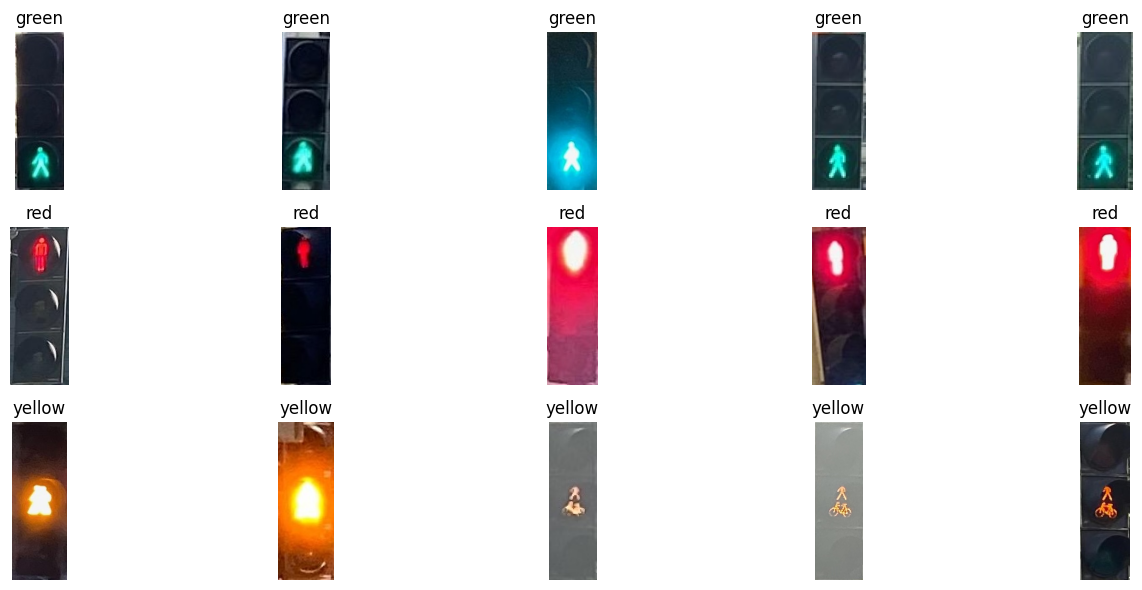

In [10]:
# ## Display validation images

# Get original dataset without transforms (so we see images as they are)
val_dataset_raw = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=transforms.ToTensor())

# Take first 10 images
fig, axes = plt.subplots(len(CLASS_NAMES), len(CLASS_NAMES[0]), figsize=(15, 6))
axes = axes.flatten()

for i in range(len(val_dataset)):
    img, label = val_dataset_raw[i]
    img = img.permute(1, 2, 0).numpy()  # convert from (C,H,W) to (H,W,C)

    axes[i].imshow(img)
    axes[i].set_title(CLASS_NAMES[label])
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## 3. Training Function

We define a reusable function `train_model` that:
- Runs training for a given number of epochs.
- Computes training and validation losses.
- Tracks validation accuracy per epoch.
- Saves the trained model checkpoint to the `RUNS_DIR` folder.
- The function returns training/validation losses and accuracies so we can later plot them.

In [15]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4, run_name="baseline"):
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=lr)

  train_losses, val_losses, val_accuracies = [], [], []

  for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
      imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
      optimizer.zero_grad()
      outputs = model(imgs)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()
      running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    correct, total, val_loss = 0, 0, 0.0
    with torch.no_grad():
      for imgs, labels in val_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        val_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    accuracy = correct / total
    val_losses.append(avg_val_loss)
    val_accuracies.append(accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {accuracy:.4f}")

  # Save model
  run_date = datetime.now().strftime('%Y%m%d_%H%M%S')
  os.makedirs(RUNS_DIR, exist_ok=True)
  save_path = os.path.join(RUNS_DIR, f"{run_date}_{run_name}.pth")
  torch.save(model.state_dict(), save_path)

  return train_losses, val_losses, val_accuracies, save_path


## 4. Models Training

Now we can train several models with different hyperparameters.
Here are the 5 configurations we will try:
| Run Name       | Learning Rate | Epochs | Batch Size |
|----------------|---------------|--------|------------|
| baseline       | 1e-4          | 30     | 8          |
| low_lr         | 5e-5          | 30     | 8          |
| high_lr        | 5e-4          | 30     | 16         |
| bigger_bs      | 1e-4          | 30     | 32         |
| longer_train   | 1e-4          | 50     | 16         |

In [16]:
# Load pretrained Swin Transformer model
model = timm.create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=NUM_CLASSES)
model.to(DEVICE);

In [17]:
# Run Experiments

import pandas as pd
from datetime import datetime
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Define different experiments (hyperparameters)
experiments = {
    "baseline":     {"epochs": 30, "lr": 1e-4, "batch_size": 8},
    "low_lr":       {"epochs": 30, "lr": 5e-5, "batch_size": 8},
    "high_lr":      {"epochs": 30, "lr": 5e-4, "batch_size": 16},
    "bigger_bs":    {"epochs": 30, "lr": 1e-4, "batch_size": 32},
    "longer_train": {"epochs": 50, "lr": 1e-4, "batch_size": 16},
}

# Create runs directory
os.makedirs(RUNS_DIR, exist_ok=True)

# Store results in a list
results_table = []

for run_name, params in experiments.items():
    print(f"\n🚀 Starting run: {run_name}")

    # Update DataLoader if batch size changes
    train_loader = DataLoader(train_dataset, batch_size=params["batch_size"], shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_dataset, batch_size=params["batch_size"], shuffle=False, num_workers=2)

    # Fresh model for each run
    model = timm.create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=NUM_CLASSES)
    model = model.to(DEVICE)

    # Train
    train_losses, val_losses, val_accs, save_path = train_model(
        model, train_loader, val_loader,
        epochs=params["epochs"], lr=params["lr"], run_name=run_name
    )

    # ---- Evaluation on validation set ----
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="macro")  # balanced across classes
    report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True)

    # Store results in table
    results_table.append({
        "run_name": run_name,
        "epochs": params["epochs"],
        "lr": params["lr"],
        "batch_size": params["batch_size"],
        "val_accuracy": acc,
        "val_f1_macro": f1,
        "model_path": save_path,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accs": val_accs,
    })



🚀 Starting run: baseline
Epoch [1/30] Train Loss: 0.9880, Val Loss: 0.5623, Val Acc: 0.8667
Epoch [2/30] Train Loss: 0.5132, Val Loss: 0.1716, Val Acc: 1.0000
Epoch [3/30] Train Loss: 0.0691, Val Loss: 0.0454, Val Acc: 1.0000
Epoch [4/30] Train Loss: 0.0612, Val Loss: 0.0486, Val Acc: 1.0000
Epoch [5/30] Train Loss: 0.0601, Val Loss: 0.0093, Val Acc: 1.0000
Epoch [6/30] Train Loss: 0.0739, Val Loss: 0.1066, Val Acc: 0.9333
Epoch [7/30] Train Loss: 0.0501, Val Loss: 0.2703, Val Acc: 0.8667
Epoch [8/30] Train Loss: 0.0440, Val Loss: 0.0382, Val Acc: 1.0000
Epoch [9/30] Train Loss: 0.0435, Val Loss: 0.0156, Val Acc: 1.0000
Epoch [10/30] Train Loss: 0.2443, Val Loss: 0.0292, Val Acc: 1.0000
Epoch [11/30] Train Loss: 0.0446, Val Loss: 0.3093, Val Acc: 0.8000
Epoch [12/30] Train Loss: 0.0293, Val Loss: 0.1646, Val Acc: 0.9333
Epoch [13/30] Train Loss: 0.0032, Val Loss: 0.1061, Val Acc: 0.9333
Epoch [14/30] Train Loss: 0.0037, Val Loss: 0.0844, Val Acc: 0.9333
Epoch [15/30] Train Loss: 0.002

This table allows us to quickly identify the best performing models.

In [22]:
# Convert to DataFrame for easy comparison
results_df = pd.DataFrame(results_table)
results_df.iloc[:, 0:6]

,run_name,epochs,lr,batch_size,val_accuracy,val_f1_macro
0,baseline,30,0.00010,8,0.933333,0.93266
1,low_lr,30,0.00005,8,1.000000,1.00000
2,high_lr,30,0.00050,16,0.733333,0.68254
3,bigger_bs,30,0.00010,32,0.933333,0.93266
4,longer_train,50,0.00010,16,1.000000,1.00000


- Baseline (lr=1e-4, bs=8, 30 epochs) → val_acc=0.93, val_f1=0.93

- Low LR (5e-5) → 1.0, so lowering LR improved accuracy

- High LR (5e-4) → dropped to 0.73, unstable training

- Bigger batch size (32) → still 0.93, so batch size isn’t the bottleneck

- Longer training (50 epochs) → accuracy reach 1 (similar to Low LR)

## 5. Validation Plots

For each run, we plot:

- **Loss curves**: training loss vs validation loss across epochs.
- **Validation accuracy curve**: to see how quickly and stably accuracy improves.

The grid of plots makes it easy to visually compare the behavior of different experiments.


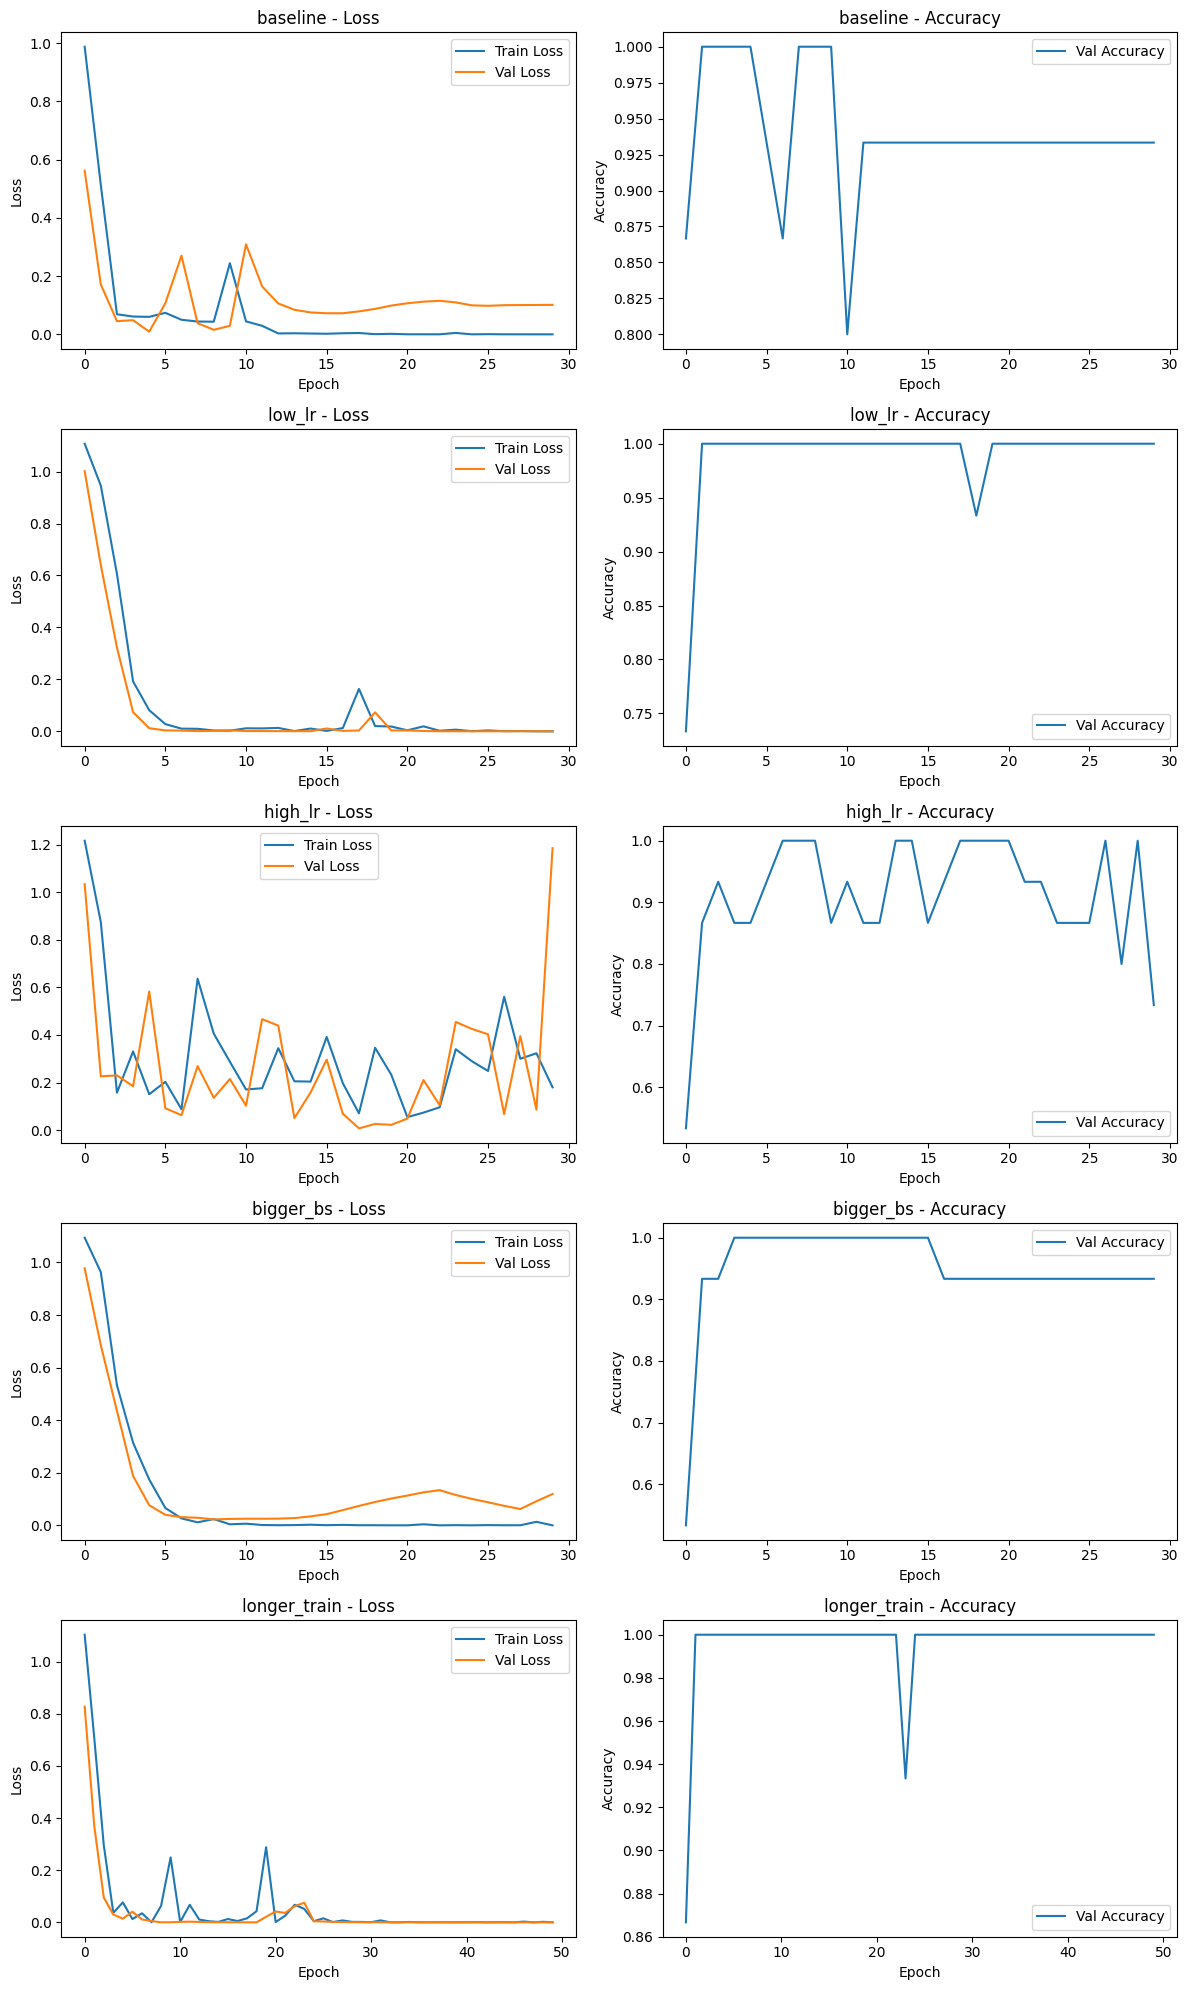

In [19]:
# ## 8. Plot all experiments in grids

n_runs = len(results_df)
fig, axes = plt.subplots(n_runs, 2, figsize=(12, 4 * n_runs))

for i, row in results_df.iterrows():
    # Loss curves
    axes[i, 0].plot(row["train_losses"], label="Train Loss")
    axes[i, 0].plot(row["val_losses"], label="Val Loss")
    axes[i, 0].set_title(f"{row['run_name']} - Loss")
    axes[i, 0].set_xlabel("Epoch")
    axes[i, 0].set_ylabel("Loss")
    axes[i, 0].legend()

    # Validation accuracy
    axes[i, 1].plot(row["val_accs"], label="Val Accuracy")
    axes[i, 1].set_title(f"{row['run_name']} - Accuracy")
    axes[i, 1].set_xlabel("Epoch")
    axes[i, 1].set_ylabel("Accuracy")
    axes[i, 1].legend()

plt.tight_layout()
plt.show()


We will select the low learning rate run as its accuracy is better, presenting no sign of overfitting.  
Let's make confusion matrix to show how well the model performs per class.

Loading baseline model: /content/drive/MyDrive/Computer_Vision_Project/runs/swin_lights/20250925_192601_low_lr.pth


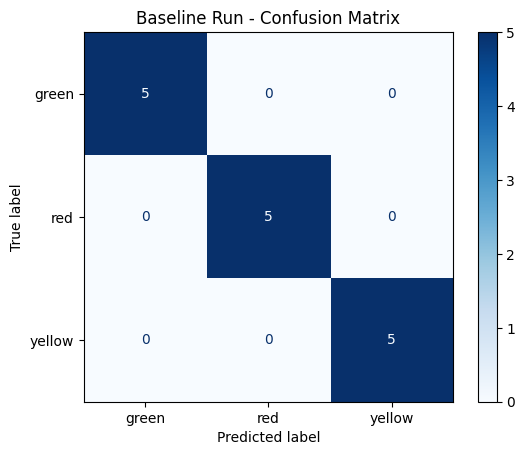

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from pathlib import Path


# --- Reload the baseline model ---
try:
  low_lr_path = results_df.loc[results_df["run_name"]=="low_lr", "model_path"].values[0]
except:
  # low_lr_path = "/content/drive/MyDrive/Computer_Vision_Project/runs/swin_lights/20250925_192601_low_lr.pth"
  low_lr_path = Path(RUNS_DIR) / "20250925_192601_low_lr.pth"
print("Loading baseline model:", low_lr_path)

low_lr_model = timm.create_model("swin_tiny_patch4_window7_224", pretrained=False, num_classes=NUM_CLASSES)
low_lr_model.load_state_dict(torch.load(low_lr_path, map_location=DEVICE))
low_lr_model = low_lr_model.to(DEVICE)
low_lr_model.eval()

# --- Collect predictions on validation set ---
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = low_lr_model(imgs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- Confusion matrix ---
cm = confusion_matrix(all_labels, all_preds, labels=range(NUM_CLASSES))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap="Blues", values_format="d")
plt.title("Baseline Run - Confusion Matrix")
plt.show()


Again, with such a small dataset, these seem too perfect to be true!  
But there are two elements to consider:
- The dataset is not challenging, the colors are very distinct and their position in the image is always the same.
- The images our model will analyze in real pratice won't be a lot different from the training and validation ones.
So we can expect a good performance of this SWIN classifier in real life.

## 6. Summary

We successfully fine-tuned a **Swin Transformer Tiny** on a small dataset of cropped traffic light images.  
The **low learning rate configuration (lr=5e-5, batch size=8, 30 epochs)** gave the most stable and accurate results, reaching perfect validation accuracy.  

While the dataset is very small (57 training and 15 validation images), the model benefits from **transfer learning**: it was initialized from a version pretrained on ImageNet, which gives it strong generalization ability even with limited data.  

The results may look “too perfect to be true,” but in practice, the traffic lights our model will face are visually very similar to the training ones.  
Therefore, we will **use the low learning rate model as is**, since it already achieves excellent performance for our intended application.
